# Midterm Project Code for MSDM 5003

Author: LAN, Tianwei 藍天蔚<br>
ID: 21230969<br>
Email: tlanaa@connect.ust.hk

In [ ]:
# General Settings
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

np.random.seed(21230969)

def exp_decay(t, tau):
    """ Theoretical Form of Directional Autocorrelation Function """
    return np.exp(-t / tau)

def linear(t, slope):
    """ MSD long-term linear fitting """
    return slope * t

In [ ]:
# Single-track integrator
def active_brownian_2D(v, DR, dt, n_steps, x0=0., y0=0., phi0=0.):
    """
    Generate a single 2D active Brownian particle trajectory
    Returns: t, x, y, phi (all arrays of length n_steps+1)
    """
    t = np.arange(n_steps + 1) * dt
    x = np.empty(n_steps + 1)
    y = np.empty(n_steps + 1)
    phi = np.empty(n_steps + 1)
    
    x[0], y[0], phi[0] = x0, y0, phi0
    
    sigma_phi = np.sqrt(2 * DR * dt)
    
    for i in range(n_steps):
        phi[i+1] = phi[i] + sigma_phi * np.random.randn()
        x[i+1]  = x[i]  + v * np.cos(phi[i]) * dt
        y[i+1]  = y[i]  + v * np.sin(phi[i]) * dt
    
    return t, x, y, phi

In [ ]:
# Calculation of Directional Autocorrelation Function
def compute_dir_corr(phi, dt, max_lag):
    """
    Calculate n(t)·n(0) = cos(phi(t)-phi(0)) from a single phi sequence
    max_lag: Maximum lag steps
    Returns: lag_times, corr (length max_lag+1)
    """
    n = len(phi)
    corr = np.empty(max_lag + 1)
    for lag in range(max_lag + 1):
        delta = phi[lag:n] - phi[0:n-lag]
        corr[lag] = np.mean(np.cos(delta))
    lag_times = np.arange(max_lag + 1) * dt
    return lag_times, corr

In [ ]:
# MSD Calculation
def compute_msd(x, y):
    """
    For a single trajectory, MSD(t) = <[r(t)-r(0)]^2>
    Returns: msd (length same as x)
    """
    dr2 = (x - x[0])**2 + (y - y[0])**2
    return dr2

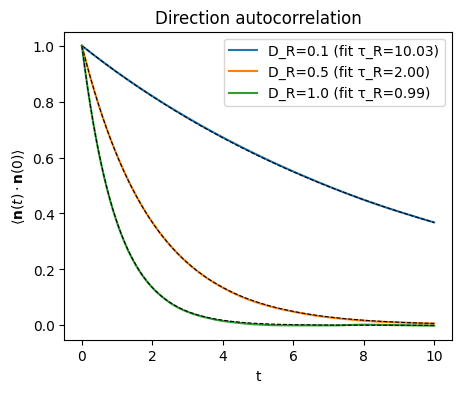

In [26]:
# Batch simulation & directional autocorrelation

from numba import njit, prange

# Parameters
DR_list   = np.array([0.1, 0.5, 1.0])
v_fixed   = 1.0
dt        = 0.01
n_steps   = 10_000
max_lag   = 1_000
N_traj    = 1_000

tauR_fit  = np.empty_like(DR_list)

# Parallel Computation 
@njit(parallel=True, fastmath=True)
def batch_dir_corr(phi_stack, max_lag):
    """
    phi_stack: (N_traj, n_steps+1)  
    Returns: (max_lag+1,) Average autocorrelation
    """
    N, L = phi_stack.shape
    corr = np.zeros(max_lag + 1)
    for lag in prange(max_lag + 1):
        tmp = 0.0
        count = 0
        for j in range(N):
            for i in range(L - lag):
                tmp += np.cos(phi_stack[j, i + lag] - phi_stack[j, i])
                count += 1
        corr[lag] = tmp / count
    return corr

plt.figure(figsize=(5, 4))
for idx, DR in enumerate(DR_list):
    sigma = np.sqrt(2 * DR * dt)
    dphi  = sigma * np.random.randn(N_traj, n_steps)
    phi   = np.empty((N_traj, n_steps + 1))
    phi[:, 0] = 0.0
    phi[:, 1:] = np.cumsum(dphi, axis=1)
    
    t_lag = np.arange(max_lag + 1) * dt
    corr_mean = batch_dir_corr(phi, max_lag)
    
    popt, _ = curve_fit(exp_decay, t_lag, corr_mean, p0=1/DR)
    tauR_fit[idx] = popt[0]
    
    plt.plot(t_lag, corr_mean, label=f'D_R={DR} (fit τ_R={popt[0]:.2f})')
    plt.plot(t_lag, exp_decay(t_lag, 1/DR), 'k--', lw=0.8)

plt.xlabel('t')
plt.ylabel(r'$\langle \mathbf{n}(t)\cdot\mathbf{n}(0)\rangle$')
plt.title('Direction autocorrelation')
plt.legend()
plt.savefig("fig1_corr.png")
plt.show()

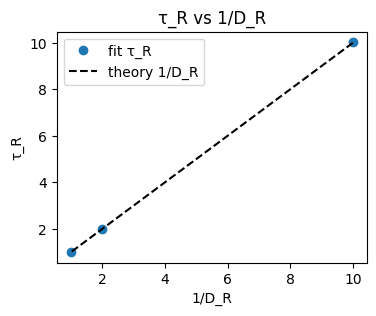

D_R    theory_τ_R=1/D_R    fit_τ_R
 0.1          10.000         10.027
 0.5           2.000          1.997
 1.0           1.000          0.994


In [27]:
# Verify τ_R = 1/D_R
plt.figure(figsize=(4,3))
plt.plot(1/DR_list, tauR_fit, 'o', label='fit τ_R')
plt.plot(1/DR_list, 1/DR_list, 'k--', label='theory 1/D_R')
plt.xlabel('1/D_R')
plt.ylabel('τ_R')
plt.title('τ_R vs 1/D_R')
plt.legend()
plt.savefig("fig2_dr.png")
plt.show()

print('D_R    theory_τ_R=1/D_R    fit_τ_R')
for dr, tf in zip(DR_list, tauR_fit):
    print(f'{dr:4.1f}        {1/dr:8.3f}       {tf:8.3f}')

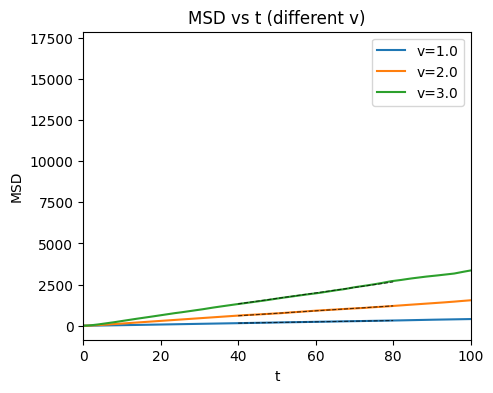

In [28]:
# Batch Simulation & MSD

# Parameters
DR_fixed  = 0.5
tau_R     = 1/DR_fixed
v_list    = np.array([1.0, 2.0, 3.0])
n_steps   = 50_000
sample_t  = np.arange(0, n_steps+1) * dt

D_eff_sim = np.empty_like(v_list)

@njit(parallel=True, fastmath=True)
def batch_msd(v, DR, dt, n_steps, N_traj):
    """
    Generate N_traj trajectories at once and calculate the average MSD.
    Return: (n_steps+1,) average MSD
    """
    msd_sum = np.zeros(n_steps + 1)
    sigma_phi = np.sqrt(2 * DR * dt)
    
    for j in prange(N_traj):
        phi = np.empty(n_steps + 1)
        x   = np.empty(n_steps + 1)
        y   = np.empty(n_steps + 1)
        phi[0] = 0.0
        x[0]   = 0.0
        y[0]   = 0.0
        
        # single trajectory
        for i in range(n_steps):
            phi[i+1] = phi[i] + sigma_phi * np.random.randn()
            x[i+1]   = x[i] + v * np.cos(phi[i]) * dt
            y[i+1]   = y[i] + v * np.sin(phi[i]) * dt
        
        # cumulative MSD
        dr2 = (x - x[0])**2 + (y - y[0])**2
        msd_sum += dr2
    
    return msd_sum / N_traj


plt.figure(figsize=(5, 4))
for idx, v in enumerate(v_list):
    msd_mean = batch_msd(v, DR_fixed, dt, n_steps, N_traj)
    
    mask = (sample_t >= 20 * tau_R) & (sample_t <= 40 * tau_R)
    popt, _ = curve_fit(linear, sample_t[mask], msd_mean[mask])
    D_eff_sim[idx] = popt[0] / 4          # MSD = 4 D_eff t
    
    plt.plot(sample_t, msd_mean, label=f'v={v}')
    plt.plot(sample_t[mask], linear(sample_t[mask], popt[0]),
             'k--', lw=0.8, alpha=0.7)

plt.xlabel('t')
plt.ylabel('MSD')
plt.title('MSD vs t (different v)')
plt.legend()
plt.xlim(0, 100)
plt.savefig("fig3_msd.png")
plt.show()

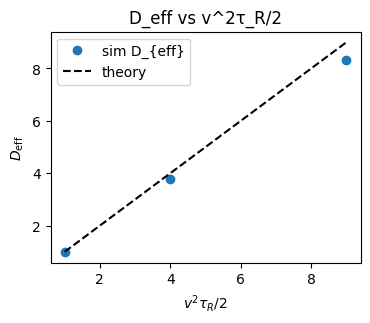

v    theory_D_eff    sim_D_eff    relative deviation(%)
1.0       1.000        0.984      -1.6
2.0       4.000        3.772      -5.7
3.0       9.000        8.306      -7.7


In [29]:
# Verify D_eff = v²τ_R / 2
theory_D = v_list**2 * tau_R / 2
plt.figure(figsize=(4,3))
plt.plot(theory_D, D_eff_sim, 'o', label='sim D_{eff}')
plt.plot(theory_D, v_list**2 * tau_R / 2, 'k--', label='theory')
plt.xlabel(r'$v^2\tau_R/2$')
plt.ylabel(r'$D_{\mathrm{eff}}$')
plt.title('D_eff vs v^2τ_R/2')
plt.legend()
plt.savefig("fig4_deff.png")
plt.show()

print('v    theory_D_eff    sim_D_eff    relative deviation(%)')
for vv, th, sim in zip(v_list, theory_D, D_eff_sim):
    print(f'{vv:3.1f}     {th:7.3f}      {sim:7.3f}     {(sim/th-1)*100:5.1f}')